# Module 18: Logistics & Cross-Border Trade Analytics
## Objective: Optimizing the flow of goods through difficult terrain and busy borders.

Logistics is the backbone of the KPK economy. In this module, we use geospatial 
data to track border efficiency, time-series analysis for Karkhano Market 
forecasting, and physics-based modeling to improve fleet fuel efficiency.

### 1. Analyzing Truck Turnaround Time (TAT)
We measure the time from entry at the checkpoint to clearance. By identifying 
the "Wait Time Distribution," we can recommend optimal arrival windows.

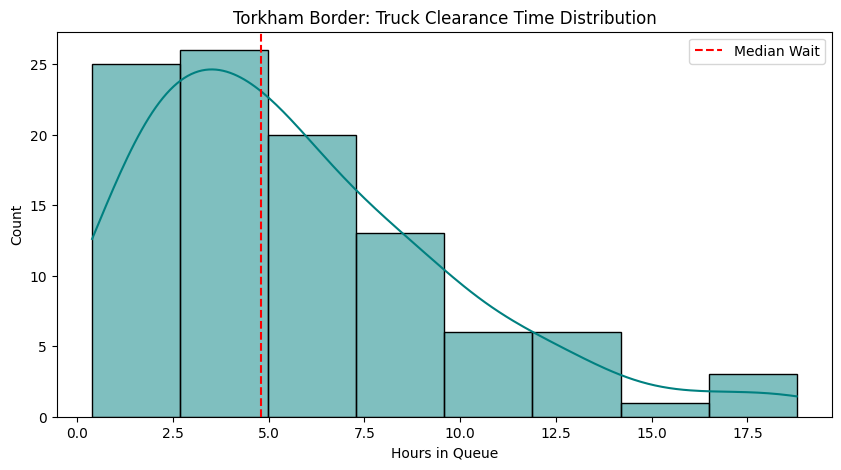

Median Clearance Time: 4.80 hours


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Simulate 100 trucks at Torkham Border
truck_ids = range(101, 201)
clearance_time = np.random.gamma(shape=2, scale=3, size=100) # Right-skewed wait times

torkham_df = pd.DataFrame({
    'Truck_ID': truck_ids,
    'Wait_Hours': clearance_time
})

# Visualization: Wait Time Distribution
plt.figure(figsize=(10, 5))
sns.histplot(torkham_df['Wait_Hours'], kde=True, color='teal')
plt.axvline(torkham_df['Wait_Hours'].median(), color='red', linestyle='--', label='Median Wait')
plt.title("Torkham Border: Truck Clearance Time Distribution")
plt.xlabel("Hours in Queue")
plt.legend()
plt.show()

print(f"Median Clearance Time: {torkham_df['Wait_Hours'].median():.2f} hours")

### 2. Inventory Optimization
We use a simple moving average and seasonal indices to predict the next month's 
demand for electronics. 

The formula for the Forecast ($F_t$) is:
$$F_t = \frac{1}{n} \sum_{i=1}^{n} A_{t-i}$$
Where $A$ is actual sales and $n$ is the number of periods.

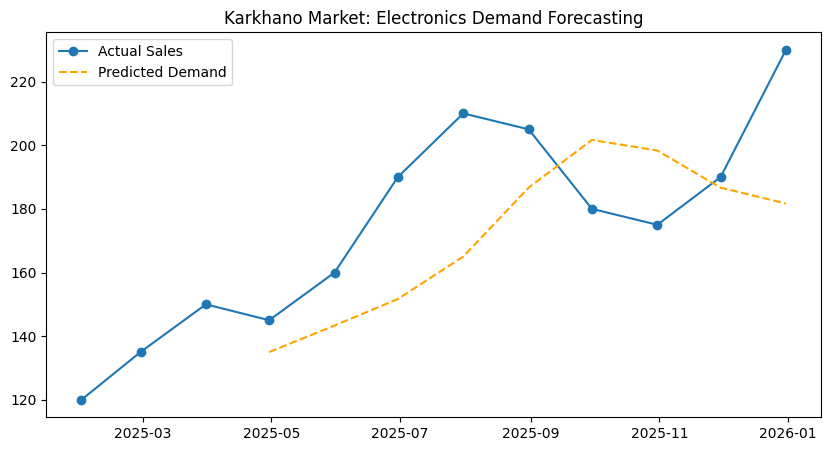

In [2]:
# Monthly Sales of Smart Watches in a Karkhano Shop
months = pd.date_range(start='2025-01-01', periods=12, freq='ME')
sales = [120, 135, 150, 145, 160, 190, 210, 205, 180, 175, 190, 230] # High EOY sales

sales_df = pd.DataFrame({'Sales': sales}, index=months)

# 3-Month Moving Average Forecast
sales_df['Forecast'] = sales_df['Sales'].rolling(window=3).mean().shift(1)

plt.figure(figsize=(10, 5))
plt.plot(sales_df['Sales'], label='Actual Sales', marker='o')
plt.plot(sales_df['Forecast'], label='Predicted Demand', linestyle='--', color='orange')
plt.title("Karkhano Market: Electronics Demand Forecasting")
plt.legend()
plt.show()

### 3. Fleet Analytics: The Indus Highway
Fuel efficiency ($E$) is often modeled as:
$$E = \frac{Distance}{Fuel_{consumed}}$$
On the Indus Highway, we must also account for **Load Weight**.

In [3]:
# Trip data for a fleet of 10 trucks
fleet_data = pd.DataFrame({
    'Truck_Type': ['6-Wheeler', '10-Wheeler', '10-Wheeler', 'Trailer', 'Trailer'],
    'Load_Tons': [10, 25, 22, 40, 38],
    'Fuel_Used_Liters': [80, 150, 140, 280, 260],
    'Distance_KM': [400, 400, 400, 400, 400]
})

# Calculate KM per Liter
fleet_data['KM_per_Liter'] = fleet_data['Distance_KM'] / fleet_data['Fuel_Used_Liters']

# Calculate Cost per Ton-KM (Assume Fuel Price = 280 PKR)
fleet_data['Cost_per_Ton_KM'] = (fleet_data['Fuel_Used_Liters'] * 280) / (fleet_data['Load_Tons'] * fleet_data['Distance_KM'])

print("Fleet Efficiency Report:")
display(fleet_data.sort_values(by='Cost_per_Ton_KM'))

Fleet Efficiency Report:


,Truck_Type,Load_Tons,Fuel_Used_Liters,Distance_KM,KM_per_Liter,Cost_per_Ton_KM
1,10-Wheeler,25,150,400,2.666667,4.200000
2,10-Wheeler,22,140,400,2.857143,4.454545
4,Trailer,38,260,400,1.538462,4.789474
3,Trailer,40,280,400,1.428571,4.900000
0,6-Wheeler,10,80,400,5.000000,5.600000


### Student Exercise: The Mountain Logistics Planner
**Goal**: Optimize a delivery route from Peshawar to Chitral.
1. Create a DataFrame with 5 segments of a road trip, including:
    - **Segment Name** (e.g., Lowari Tunnel Approach).
    - **Distance** (KM).
    - **Incline_Gradient** (Degrees).
2. Write a function that calculates "Estimated Time" where:
    - Base speed = 60 KM/h.
    - Speed decreases by 5 KM/h for every 2 degrees of incline.
3. **Wildcard Analysis**: Add a column for 'Alternative Transport' (Air Cargo). If 
   the total road time exceeds 10 hours, flag the shipment for "Air Priority."
4. Create a **Bar Chart** comparing the 'Fuel Cost' of each segment.